In [22]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

np.random.seed(0)

In [23]:
# Load the data
data = pd.read_csv('Iris.csv')
data = data.drop('Id', axis=1)
data.drop(['SepalLengthCm', 'SepalWidthCm'], axis=1, inplace=True)
print(data.head())
print(data.shape)

   PetalLengthCm  PetalWidthCm      Species
0            1.4           0.2  Iris-setosa
1            1.4           0.2  Iris-setosa
2            1.3           0.2  Iris-setosa
3            1.5           0.2  Iris-setosa
4            1.4           0.2  Iris-setosa
(150, 3)


In [24]:
data['target'] = data['Species'].map({'Iris-setosa': 0, 'Iris-virginica': 2, 'Iris-versicolor': 1})
print(data.head())

   PetalLengthCm  PetalWidthCm      Species  target
0            1.4           0.2  Iris-setosa       0
1            1.4           0.2  Iris-setosa       0
2            1.3           0.2  Iris-setosa       0
3            1.5           0.2  Iris-setosa       0
4            1.4           0.2  Iris-setosa       0


In [25]:
# Softmax classification 
# y debe estar en codificacion onehot
y = pd.get_dummies(data['target']).values
print(y.shape)


(150, 3)


In [26]:
# Construimos X
X = data[['PetalLengthCm', 'PetalWidthCm']].values
X = np.c_[np.ones(X.shape[0]), X]
print(X.shape)

(150, 3)


In [27]:
# Construimos w
w = np.random.rand(3, X.shape[1])
print(w.shape)

(3, 3)


In [28]:
# Definimos la funcion softmax
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)


In [29]:
# Definimos el costo 
def costo(y, P):
    return -(1 / y.shape[0]) * np.sum(y * np.log(P))

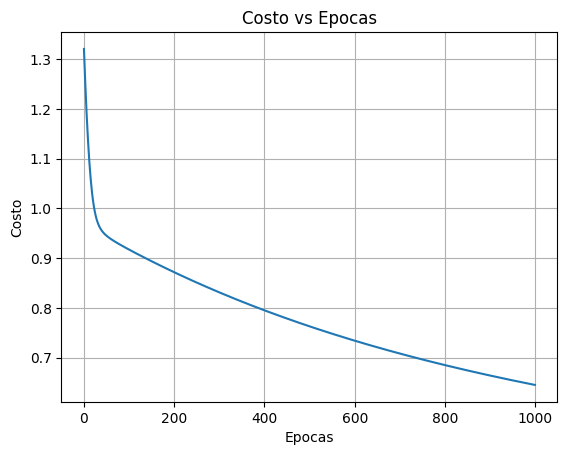

In [30]:
alfa = 0.01
epocas = 1000
J = []

for i in range(epocas):
    z = np.dot(X, w.T)
    P = softmax(z)
    grad = np.dot((P - y).T, X) / X.shape[0]
    w = w - alfa * grad
    J.append(costo(y, P))
    
# Graficamos 
plt.plot(J)
plt.xlabel('Epocas')
plt.ylabel('Costo')
plt.title('Costo vs Epocas')
plt.grid()
plt.show()

In [31]:
#hacemos la prediccion
y_pred = softmax( np.dot(X,w.T))
P_pred = np.argmax(y_pred,axis=1)
print(P_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 2 2 1 2 1 2 2 2 2 1 2 1 2 2 2 1
 2 2 2 2 2 1 1 1 1 2 2 2 2 2 2 2 1 2 1 1 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


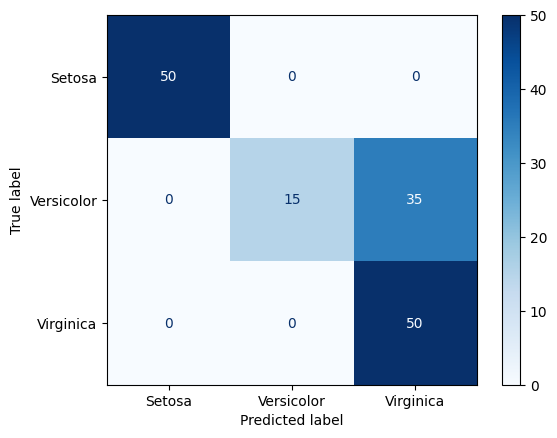

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Generar la matriz de confusión
cm = confusion_matrix(data['target'], P_pred)
# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Setosa', 'Versicolor', 'Virginica'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [33]:
# Calcular VP, FP, FN y VN para Iris-setosa
VP = np.sum((data['target'] == P_pred) & (P_pred == 0))  # Verdaderos positivos para la clase 0
FP = np.sum((data['target'] != P_pred) & (P_pred == 0))  # Falsos positivos para la clase 0
FN = np.sum((data['target'] == 0) & (P_pred != 0))       # Falsos negativos para la clase 0
VN = np.sum((data['target'] == P_pred) & (P_pred != 0))  # Verdaderos negativos para otras clases


In [34]:
# Calculamos precisión para Setosa
precision_setosa = VP / (VP + FP)

print(f"Precisión para Iris-setosa: {precision_setosa:.2f}")

Precisión para Iris-setosa: 1.00


In [35]:
# Calculamos Recall para Iris Setosa    
recall_setosa = VP/(VP+FN)
print(f'El valor de Recall para Iris-Setosa es: {recall_setosa}')

El valor de Recall para Iris-Setosa es: 1.0


In [36]:
# Calculamos Exactitud para Iris-Setosa
TOTAL = VP + VN + FP + FN
print(f'El valor de Exactitud para Iris-Setosa es: {(VP+VN)/(TOTAL)} ')

El valor de Exactitud para Iris-Setosa es: 1.0 


In [37]:
# Calculamos el valor de F1

F1 = 2* (precision_setosa * recall_setosa) / (precision_setosa + recall_setosa)

print(f'El valor de F1 para la Iris Setosa es: {F1}')

El valor de F1 para la Iris Setosa es: 1.0


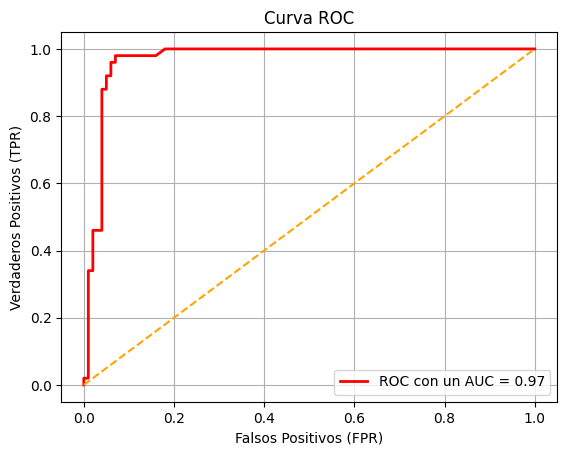

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcular las probabilidades predichas por el modelo
y_scores = softmax(np.dot(X, w.T))[:, 1]  # Usar las probabilidades de la clase positiva (por ejemplo, clase 1)

# Obtener la curva ROC
fpr, tpr, thresholds = roc_curve(data['target'] == 1, y_scores)  # Aquí '1' es la clase positiva

# Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC con un AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='orange', linestyle='--')  # Línea diagonal (clasificador aleatorio)
plt.xlabel('Falsos Positivos (FPR)')
plt.ylabel('Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid()
plt.show()
